In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 10 sentences across exactly 3 topics: Cricket, Cooking, Cybersecurity
sentences = [
    "Virat Kohli scored a century in the final match.",
    "The bowler delivered a perfect yorker to dismiss the batsman.",
    "India won the cricket match by chasing the target in the last over.",
    "The captain set an aggressive field during the powerplay.",
    "I added garlic and butter to the pan before cooking the pasta.",
    "The chef baked a chocolate cake at 180 degrees for thirty minutes.",
    "Fresh vegetables and spices made the curry taste much better.",
    "The company installed a firewall to block unauthorized network access.",
    "Phishing emails can trick users into revealing their passwords.",
    "Multi-factor authentication improves account security against hackers."
]

labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cybersecurity 1", "Cybersecurity 2", "Cybersecurity 3"
]

print("Total sentences:", len(sentences))
for i, sentence in enumerate(sentences, start=1):
    print(f"{i}. {sentence}")

Total sentences: 10
1. Virat Kohli scored a century in the final match.
2. The bowler delivered a perfect yorker to dismiss the batsman.
3. India won the cricket match by chasing the target in the last over.
4. The captain set an aggressive field during the powerplay.
5. I added garlic and butter to the pan before cooking the pasta.
6. The chef baked a chocolate cake at 180 degrees for thirty minutes.
7. Fresh vegetables and spices made the curry taste much better.
8. The company installed a firewall to block unauthorized network access.
9. Phishing emails can trick users into revealing their passwords.
10. Multi-factor authentication improves account security against hackers.


In [3]:
vectorizer = TfidfVectorizer()
embeddings = vectorizer.fit_transform(sentences)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (10, 80)


In [4]:
similarity_matrix = cosine_similarity(embeddings, embeddings)

similarity_df = pd.DataFrame(similarity_matrix, index=labels, columns=labels)
print("10x10 Cosine Similarity Matrix:")
similarity_df

10x10 Cosine Similarity Matrix:


,Cricket 1,Cricket 2,Cricket 3,Cricket 4,Cooking 1,Cooking 2,Cooking 3,Cybersecurity 1,Cybersecurity 2,Cybersecurity 3
Cricket 1,1.000000,0.056438,0.235910,0.054795,0.050793,0.023944,0.025601,0.027465,0.0,0.0
Cricket 2,0.056438,1.000000,0.130282,0.104243,0.164437,0.045551,0.048704,0.125580,0.0,0.0
Cricket 3,0.235910,0.130282,1.000000,0.126489,0.117250,0.055272,0.059097,0.063399,0.0,0.0
Cricket 4,0.054795,0.104243,0.126489,1.000000,0.093815,0.044225,0.047286,0.050728,0.0,0.0
Cooking 1,0.050793,0.164437,0.117250,0.093815,1.000000,0.040995,0.124202,0.113018,0.0,0.0
Cooking 2,0.023944,0.045551,0.055272,0.044225,0.040995,1.000000,0.020662,0.022167,0.0,0.0
Cooking 3,0.025601,0.048704,0.059097,0.047286,0.124202,0.020662,1.000000,0.023701,0.0,0.0
Cybersecurity 1,0.027465,0.125580,0.063399,0.050728,0.113018,0.022167,0.023701,1.000000,0.0,0.0
Cybersecurity 2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
Cybersecurity 3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0


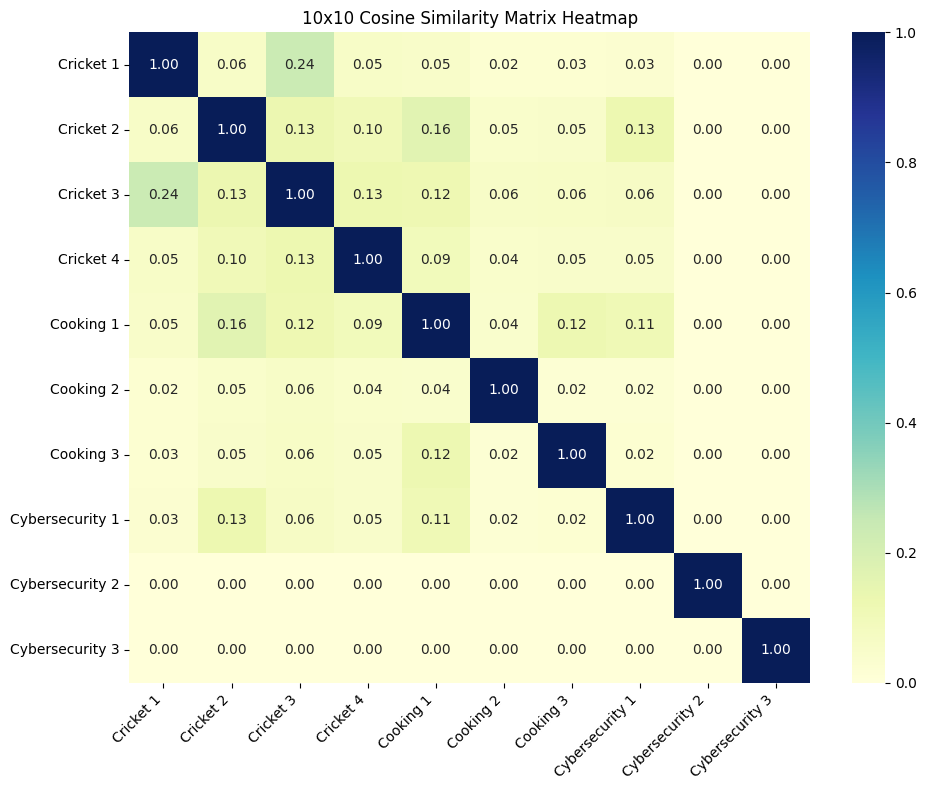

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("10x10 Cosine Similarity Matrix Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
query_sentence = "The bowler took three wickets in one over"

query_embedding = vectorizer.transform([query_sentence])
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

result_df = pd.DataFrame({
    "Sentence": sentences,
    "Similarity Score": query_similarities
})

top_2 = result_df.sort_values(by="Similarity Score", ascending=False).head(2).reset_index(drop=True)

print("Query Sentence:")
print(query_sentence)

print("\nTop 2 Most Similar Sentences:")
print(top_2)

Query Sentence:
The bowler took three wickets in one over

Top 2 Most Similar Sentences:
                                            Sentence  Similarity Score
0  India won the cricket match by chasing the tar...          0.404285
1  The bowler delivered a perfect yorker to dismi...          0.301121
